In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!wget -q https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -q ml-100k.zip
print("Downloaded successfully!")

replace ml-100k/allbut.pl? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/mku.sh? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/README? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u.data? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u.genre? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u.info? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u.item? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u.occupation? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u.user? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace ml-100k/u.user? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u1.base? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u1.test? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u2.base? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/u2.test? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Downloaded successfully!


In [3]:
import pandas as pd

# Load ratings
ratings = pd.read_csv('ml-100k/u.data', sep='\t',
                      names=['user_id','movie_id','rating','timestamp'])

# Load movie titles
movies = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1',
                     usecols=[0,1], names=['movie_id','title'])

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)
ratings.head()

Ratings shape: (100000, 4)
Movies shape: (1682, 2)


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


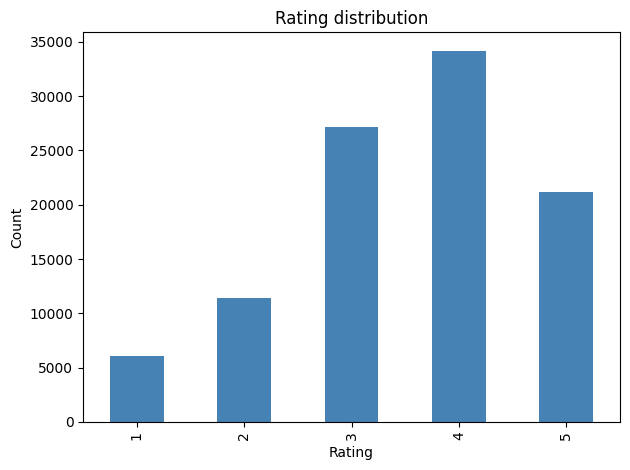

Unique users: 943
Unique movies: 1682
Average rating: 3.53


In [4]:
import matplotlib.pyplot as plt

# Rating distribution
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Rating distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("Unique users:", ratings['user_id'].nunique())
print("Unique movies:", ratings['movie_id'].nunique())
print("Average rating:", round(ratings['rating'].mean(), 2))

In [5]:
import os

# Your GitHub details — fill these in
GITHUB_USERNAME = "Manoj-R27"
GITHUB_EMAIL = "pes2ug23cs328@pesu.pes.edu"
GITHUB_TOKEN = "GITHUB_TOKEN"
REPO_NAME = "recsys-causal-rl"

# Configure git
!git config --global user.email "{GITHUB_EMAIL}"
!git config --global user.name "{GITHUB_USERNAME}"

# Clone your repo
!git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git
print("Repo cloned!")

fatal: destination path 'recsys-causal-rl' already exists and is not an empty directory.
Repo cloned!


In [6]:
import pandas as pd

# Load ratings
ratings = pd.read_csv('ml-100k/u.data', sep='\t',
                      names=['user_id','movie_id','rating','timestamp'])

# Load movie titles
movies = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1',
                     usecols=[0,1], names=['movie_id','title'])

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)
print("Average rating:", round(ratings['rating'].mean(), 2))
ratings.head()

Ratings shape: (100000, 4)
Movies shape: (1682, 2)
Average rating: 3.53


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


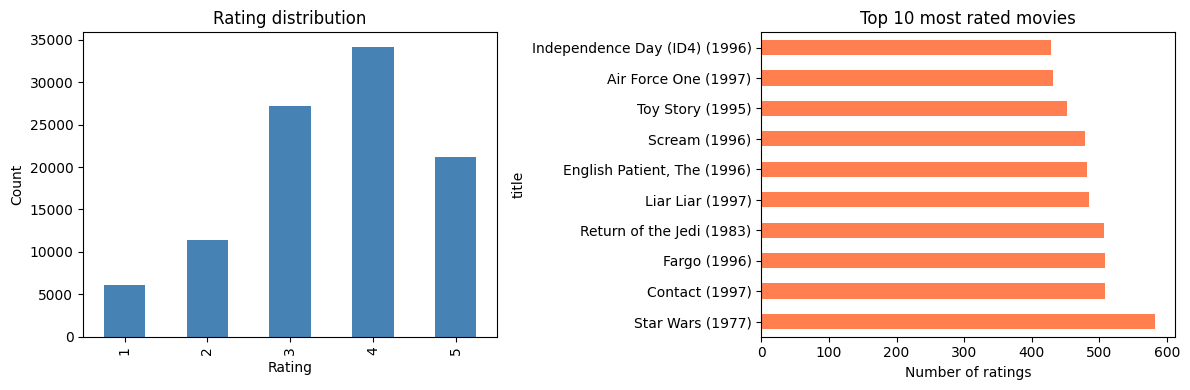

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Rating distribution
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rating distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Top 10 most rated movies
top_movies = ratings.groupby('movie_id')['rating'].count()\
             .sort_values(ascending=False).head(10)
top_movies = top_movies.reset_index().merge(movies, on='movie_id')
top_movies.plot(kind='barh', x='title', y='rating',
                ax=axes[1], color='coral', legend=False)
axes[1].set_title('Top 10 most rated movies')
axes[1].set_xlabel('Number of ratings')

plt.tight_layout()
plt.show()

In [9]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

# Build user-movie matrix
user_movie_matrix = ratings.pivot_table(
    index='user_id', columns='movie_id', values='rating').fillna(0)

# Train SVD model
svd = TruncatedSVD(n_components=50, random_state=42)
matrix_svd = svd.fit_transform(user_movie_matrix)

# User similarity
user_similarity_df = pd.DataFrame(
    cosine_similarity(matrix_svd),
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index)

print("Model trained!")
print("Variance explained:", round(svd.explained_variance_ratio_.sum(), 3))

Model trained!
Variance explained: 0.524


In [10]:
def get_recommendations(user_id, n=10):
    # Find 5 most similar users
    similar_users = user_similarity_df[user_id]\
                    .sort_values(ascending=False)[1:6].index

    # Movies this user already watched
    watched = user_movie_matrix.loc[user_id][
              user_movie_matrix.loc[user_id] > 0].index

    # Average ratings from similar users
    similar_ratings = user_movie_matrix.loc[similar_users].mean()

    # Recommend top n unwatched movies
    recommendations = similar_ratings.drop(watched)\
                      .sort_values(ascending=False).head(n)

    rec_movies = movies[movies['movie_id'].isin(recommendations.index)]
    return rec_movies['title'].values

# Test for 3 different users
for user in [1, 50, 200]:
    print(f"\nTop 5 recommendations for User {user}:")
    for i, movie in enumerate(get_recommendations(user, n=5), 1):
        print(f"  {i}. {movie}")


Top 5 recommendations for User 1:
  1. Heathers (1989)
  2. Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)
  3. Stand by Me (1986)
  4. Dave (1993)
  5. Real Genius (1985)

Top 5 recommendations for User 50:
  1. Star Wars (1977)
  2. Welcome to the Dollhouse (1995)
  3. Swingers (1996)
  4. Donnie Brasco (1997)
  5. Nixon (1995)

Top 5 recommendations for User 200:
  1. Return of the Jedi (1983)
  2. Blues Brothers, The (1980)
  3. Bridge on the River Kwai, The (1957)
  4. When Harry Met Sally... (1989)
  5. Men in Black (1997)


In [11]:
import os

# Copy notebook to repo folder
!cp /content/stage1_recsys.ipynb /content/recsys-causal-rl/

# Push to GitHub
os.chdir('/content/recsys-causal-rl')
!git add .
!git commit -m "Stage 1 complete - SVD recommendation model working"
!git push

print("Pushed to GitHub!")

cp: cannot stat '/content/stage1_recsys.ipynb': No such file or directory
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Password for 'https://GITHUB_TOKEN@github.com': No such device or address
Pushed to GitHub!


In [12]:
import os
files = os.listdir('/content')
print(files)

['.config', 'ml-100k', 'drive', 'recsys-causal-rl', 'ml-100k.zip.1', 'ml-100k.zip', 'sample_data']


In [14]:
import glob
notebooks = glob.glob('/content/drive/**/*.ipynb', recursive=True)
for nb in notebooks:
    print(nb)

/content/drive/MyDrive/Colab Notebooks/stage1_recsys.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/PES2UG23CS328 (1).ipynb
/content/drive/MyDrive/Colab Notebooks/PES2UG23CS328.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of PES2UG23CS328.ipynb
/content/drive/MyDrive/Colab Notebooks/Subscription_Service_Churn_Predictor.ipynb
/content/drive/MyDrive/Colab Notebooks/da-orange-2-student-starter-notebook-python.ipynb
/content/drive/MyDrive/Colab Notebooks/Naive_Bayes_Classifier_Boilerplate.ipynb
/content/drive/MyDrive/Colab Notebooks/Boiler_plate (1).ipynb
/content/drive/MyDrive/Colab Notebooks/Boiler_plate.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled4.ipynb
/content/drive/MyDrive/Colab Notebooks/Synthetic_Data_Driven_RAG_Evaluation_Framework.ipynb
/content/drive/MyDrive/Colab Notebooks/AdaRAG/01_dense_retrieval_fais

In [ ]:
from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')
print("Token found:", token is not None)